In [ ]:
!pip install -q transformers accelerate sentencepiece

In [ ]:
import torch
from transformers import pipeline

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
!wget -q https://raw.githubusercontent.com/lm-sys/FastChat/main/fastchat/llm_judge/data/mt_bench/question.jsonl

In [ ]:
!ls -lh question.jsonl

-rw-r--r-- 1 root root 48K Sep  4 14:12 question.jsonl


In [ ]:
import json

mt_bench = []

with open("question.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        mt_bench.append(json.loads(line))

print("Total MT-Bench questions:", len(mt_bench))

Total MT-Bench questions: 80


In [ ]:
print(mt_bench[0])

{'question_id': 81, 'category': 'writing', 'turns': ['Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.', 'Rewrite your previous response. Start every sentence with the letter A.']}


In [ ]:
from transformers import pipeline
import torch

target_llm = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-0.5B-Instruct",
    device=0 if torch.cuda.is_available() else -1
)

# Remove the conflicting max_length setting
target_llm.model.generation_config.max_length = None

print("Target LLM loaded successfully!")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Target LLM loaded successfully!


In [ ]:
question = mt_bench[0]["turns"][0]

print("Question:")
print(question)

Question:
Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.


In [ ]:
prompt = f"""
Answer the following question clearly and accurately.

Question:
{question}

Answer:
"""

result = target_llm(
    prompt,
    max_new_tokens=150,
    do_sample=False
)

answer = result[0]["generated_text"]

print("Generated Answer:")
print(answer)

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Generated Answer:

Answer the following question clearly and accurately.

Question:
Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.

Answer:
Welcome to our latest adventure in Hawaii! As we embark on this journey, we are eager to share with you some of the most memorable moments from our trip. From the vibrant culture of Hawaii to the breathtaking beauty of the islands, there is something for everyone to enjoy.
Our first stop was at the beautiful Waikiki Beach. The sand was warm and golden, and the water was crystal clear. We spent hours lounging on the beach, taking photos, and enjoying the sun. It was a perfect day to relax and soak up the sun.
Next, we visited the famous Ka'ala Lighthouse. This lighthouse is one of the oldest in the world, and it offers stunning views of the ocean. We took a boat tour around the


In [ ]:
generated_answers = []

for item in mt_bench[:5]:

    question = item["turns"][0]

    prompt = f"""Answer the following question clearly and accurately.

Question:
{question}

Answer:"""

    result = target_llm(
        prompt,
        max_new_tokens=150,
        do_sample=False
    )

    generated_text = result[0]["generated_text"]

    # Remove the prompt part
    if "Answer:" in generated_text:
        answer = generated_text.split("Answer:", 1)[1].strip()
    else:
        answer = generated_text.strip()

    generated_answers.append({
        "question_id": item["question_id"],
        "category": item["category"],
        "question": question,
        "answer": answer
    })

print("Generated answers:", len(generated_answers))

[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Generated answers: 5


In [ ]:
for item in generated_answers:

    print("=" * 80)
    print("Question ID:", item["question_id"])
    print("Category:", item["category"])

    print("\nQuestion:")
    print(item["question"])

    print("\nGenerated Answer:")
    print(item["answer"])

Question ID: 81
Category: writing

Question:
Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.

Generated Answer:
Welcome to my latest adventure in Hawaii! As I sit here on the beach, gazing at the golden sand and crystal-clear waters, I can't help but feel a sense of excitement and anticipation for what lies ahead. This is no ordinary trip; it's one that will leave me with unforgettable memories and a newfound appreciation for the beauty of Hawaii.
The first thing that struck me upon arrival was the vibrant culture of Hawaii. From the bustling streets of Honolulu to the serene beaches of Maui, there's something for everyone. The locals are friendly and welcoming, always ready to share their stories and traditions with visitors. It's like a warm hug from the past, making you feel right at home.
One of the most impressive sights I saw during my
Question ID: 82
Category: writing

Question:
Draft a professional 

In [ ]:
from huggingface_hub import login

login()

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "meta-llama/Llama-3.2-1B-Instruct"

judge_tokenizer = AutoTokenizer.from_pretrained(
    model_id
)

judge_llm = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("Llama 3.2 1B Instruct Judge loaded successfully!")

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Llama 3.2 1B Instruct Judge loaded successfully!


In [ ]:
item = generated_answers[0]

question = item["question"]
answer = item["answer"]

print("Question:", question)
print("\nAnswer:", answer)

Question: Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.

Answer: Welcome to my latest adventure in Hawaii! As I sit here on the beach, gazing at the golden sand and crystal-clear waters, I can't help but feel a sense of excitement and anticipation for what lies ahead. This is no ordinary trip; it's one that will leave me with unforgettable memories and a newfound appreciation for the beauty of Hawaii.
The first thing that struck me upon arrival was the vibrant culture of Hawaii. From the bustling streets of Honolulu to the serene beaches of Maui, there's something for everyone. The locals are friendly and welcoming, always ready to share their stories and traditions with visitors. It's like a warm hug from the past, making you feel right at home.
One of the most impressive sights I saw during my


In [ ]:
messages = [
    {
        "role": "system",
        "content": "You are an AI evaluator. Evaluate the quality of the given answer."
    },
    {
        "role": "user",
        "content": f"""
Question:
{question}

Answer:
{answer}

Give an overall quality score from 1 to 10.
Then explain your score briefly.

Score 1 means very poor.
Score 10 means excellent.
"""
    }
]

judge_prompt = judge_tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

In [ ]:
inputs = judge_tokenizer(
    judge_prompt,
    return_tensors="pt"
).to(judge_llm.device)

with torch.no_grad():
    outputs = judge_llm.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False,
        pad_token_id=judge_tokenizer.eos_token_id
    )

generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

evaluation = judge_tokenizer.decode(
    generated_tokens,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)

print("Judge Evaluation:")
print(evaluation)

Judge Evaluation:
I would give this answer a score of 8 out of 10.

The strengths of this answer are:

* The author provides a vivid description of the cultural experiences and attractions in Hawaii, which suggests a genuine interest in the local culture.
* The use of sensory details, such as the "golden sand" and "crystal-clear waters," helps to create a immersive experience for the reader.
* The author's enthusiasm and excitement about the trip are palpable, making the reader want to join them


In [ ]:
generated_answers[0]

{'question_id': 81,
 'category': 'writing',
 'question': 'Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.',
 'answer': "Welcome to my latest adventure in Hawaii! As I sit here on the beach, gazing at the golden sand and crystal-clear waters, I can't help but feel a sense of excitement and anticipation for what lies ahead. This is no ordinary trip; it's one that will leave me with unforgettable memories and a newfound appreciation for the beauty of Hawaii.\nThe first thing that struck me upon arrival was the vibrant culture of Hawaii. From the bustling streets of Honolulu to the serene beaches of Maui, there's something for everyone. The locals are friendly and welcoming, always ready to share their stories and traditions with visitors. It's like a warm hug from the past, making you feel right at home.\nOne of the most impressive sights I saw during my"}

In [ ]:
evaluations = []

for item in generated_answers:

    question = item["question"]
    answer = item["answer"]

    messages = [
        {
            "role": "system",
            "content": "You are an AI evaluator. Evaluate the quality of the given answer."
        },
        {
            "role": "user",
            "content": f"""
Question:
{question}

Answer:
{answer}

Give an overall quality score from 1 to 10.
Then briefly explain your score.
"""
        }
    ]

    judge_prompt = judge_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = judge_tokenizer(
        judge_prompt,
        return_tensors="pt",
        truncation=True
    ).to(judge_llm.device)

    with torch.no_grad():
        outputs = judge_llm.generate(
            **inputs,
            max_new_tokens=100,
            do_sample=False,
            pad_token_id=judge_tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    evaluation = judge_tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    evaluations.append({
        "question_id": item["question_id"],
        "category": item["category"],
        "question": question,
        "answer": answer,
        "evaluation": evaluation
    })

    print("=" * 80)
    print("Question ID:", item["question_id"])
    print("Evaluation:")
    print(evaluation)

Question ID: 81
Evaluation:
I would give this answer a quality score of 7 out of 10.

Here's why:

Strengths:

* The writer starts with a hook that grabs the reader's attention and sets the tone for a engaging travel blog post.
* They provide a brief description of the cultural experiences they had in Hawaii, which suggests that they were able to immerse themselves in the local culture.
* They mention specific attractions, such as the beaches and the locals, which adds to the authenticity of the experience.


Question ID: 82
Evaluation:
I would give this answer a score of 8 out of 10.

Strengths:

* The email is concise and to the point, clearly stating the purpose of the email and the areas for improvement.
* The request for feedback is specific and relevant, showing that the writer is interested in the supervisor's opinion.
* The writer provides some context about the report and its content, demonstrating a good understanding of the subject matter.

Weaknesses:

* The email could ben

In [ ]:
target_llm

TextGenerationPipeline: {'model': 'Qwen2ForCausalLM', 'dtype': 'bfloat16', 'device': 'cuda', 'input_modalities': 'text', 'output_modalities': ('text',)}

In [ ]:
def generate_answer(question):

    prompt = f"""Answer the following question clearly and accurately.

Question:
{question}

Answer:
"""

    result = target_llm(
        prompt,
        max_new_tokens=200,
        do_sample=False,
        return_full_text=False
    )

    return result[0]["generated_text"].strip()

In [ ]:
generated_answers = []

for i, item in enumerate(mt_bench):

    question = item["turns"][0]

    answer = generate_answer(question)

    generated_answers.append({
        "question_id": item["question_id"],
        "category": item["category"],
        "question": question,
        "answer": answer
    })

    print(f"{i+1}/80 completed - Question ID: {item['question_id']}")

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


1/80 completed - Question ID: 81


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


2/80 completed - Question ID: 82


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

77/80 completed - Question ID: 157


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


78/80 completed - Question ID: 158


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


79/80 completed - Question ID: 159
80/80 completed - Question ID: 160


In [ ]:
judge_llm
judge_tokenizer

TokenizersBackend(name_or_path='meta-llama/Llama-3.2-1B-Instruct', vocab_size=128000, model_max_length=131072, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|begin_of_text|>', 'eos_token': '<|eot_id|>'}, added_tokens_decoder={
	128000: AddedToken("<|begin_of_text|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128001: AddedToken("<|end_of_text|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128002: AddedToken("<|reserved_special_token_0|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128003: AddedToken("<|reserved_special_token_1|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128004: AddedToken("<|finetune_right_pad_id|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128005: AddedToken("<|reserved_special_token_2|>", rstrip=False, lstrip=False, single_word=False, normalize

In [ ]:
def create_judge_prompt(question, answer):

    prompt = f"""
You are an expert evaluator.

Your ONLY task is to evaluate the answer.

Question:
{question}

Answer:
{answer}

Evaluate the answer using these criteria:

1. Correctness
2. Relevance
3. Clarity
4. Following the instructions

Give ONE overall score from 1 to 10.

1 = Very poor
10 = Excellent

IMPORTANT:
- Do not rewrite the answer.
- Do not provide an alternative answer.
- Do not refuse the evaluation.
- Do not discuss whether you are allowed to evaluate.
- Give exactly ONE score.

Your response MUST start with:

Score: X

Then give one short reason.

Required format:

Score: X
Reason: one short sentence.
"""

    return prompt

In [ ]:
def judge_answer(question, answer):

    judge_prompt = create_judge_prompt(
        question,
        answer
    )

    # Convert prompt to tokens
    inputs = tokenizer(
        judge_prompt,
        return_tensors="pt"
    ).to(model.device)

    # Generate evaluation
    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=True,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id
        )

    # Decode only newly generated tokens
    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    evaluation = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return evaluation.strip()

In [ ]:
import re

def extract_score(text):
    """
    Extract score from different formats produced by the judge LLM.
    Returns an integer from 1-10, otherwise None.
    """

    if not text:
        return None

    # Convert to lowercase for easier matching
    text_lower = text.lower()

    patterns = [
        r"score\s*:\s*(10|[1-9])",
        r"overall quality score\s*:\s*(10|[1-9])",
        r"quality score\s*:\s*(10|[1-9])",
        r"overall score\s*:\s*(10|[1-9])",
        r"final score\s*:\s*(10|[1-9])",
        r"rating\s*:\s*(10|[1-9])",
        r"score\s+of\s+(10|[1-9])",
        r"give.*?score.*?(10|[1-9])\s*(?:out of 10)?"
    ]

    for pattern in patterns:
        match = re.search(pattern, text_lower)

        if match:
            score = int(match.group(1))

            if 1 <= score <= 10:
                return score

    return None

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "meta-llama/Llama-3.2-1B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("Tokenizer loaded:", tokenizer is not None)
print("Judge model loaded successfully!")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Tokenizer loaded: True
Judge model loaded successfully!


In [ ]:
def judge_answer(question, answer):

    judge_prompt = create_judge_prompt(
        question,
        answer
    )

    inputs = tokenizer(
        judge_prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=True,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id
        )

    # Only take newly generated tokens
    generated_tokens = outputs[0][
        inputs["input_ids"].shape[1]:
    ]

    evaluation = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return evaluation.strip()

In [ ]:
item = generated_answers[0]

evaluation = judge_answer(
    item["question"],
    item["answer"]
)

print("Judge Evaluation:")
print(evaluation)

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Judge Evaluation:
Example: Score: 8
Reason: The answer is well-structured and easy to follow.


In [ ]:
score = extract_score(evaluation)

print("Extracted Score:", score)

Extracted Score: 8


In [ ]:
item = generated_answers[0]

for run in range(5):

    evaluation = judge_answer(
        item["question"],
        item["answer"]
    )

    score = extract_score(evaluation)

    print(f"\nRun {run + 1}")
    print("Score:", score)
    print("Evaluation:", evaluation)


Run 1
Score: 9
Evaluation: Example: Score: 9
Reason: The answer provided a good balance of cultural experiences and must-see attractions.

Run 2
Score: 8
Evaluation: Example: Score: 8
Reason: The answer is engaging and informative.

Run 3
Score: 8
Evaluation: For example: Score: 8
Reason: The answer is engaging and provides valuable insights into the author's experience.

Run 4
Score: 8
Evaluation: (For example: Score: 8
Reason: The answer is clear and concise.)

Run 5
Score: 8
Evaluation: (For example: Score: 8
Reason: The answer is well-written and engaging.)


In [ ]:
import time

reliability_results = []

for i, item in enumerate(generated_answers):

    question = item["question"]
    answer = item["answer"]

    evaluations = []
    scores = []

    for run in range(3):

        evaluation = judge_answer(
            question,
            answer
        )

        score = extract_score(evaluation)

        evaluations.append(evaluation)
        scores.append(score)

        time.sleep(0.2)

    reliability_results.append({
        "question_id": item["question_id"],
        "category": item["category"],
        "question": question,
        "answer": answer,

        "judge_run_1": evaluations[0],
        "judge_run_2": evaluations[1],
        "judge_run_3": evaluations[2],

        "score_1": scores[0],
        "score_2": scores[1],
        "score_3": scores[2]
    })

    print(
        f"{i+1}/80 | "
        f"ID: {item['question_id']} | "
        f"Scores: {scores}"
    )

1/80 | ID: 81 | Scores: [8, 8, 8]
2/80 | ID: 82 | Scores: [8, 8, 9]
3/80 | ID: 83 | Scores: [8, 8, 8]
4/80 | ID: 84 | Scores: [8, 8, 8]
5/80 | ID: 85 | Scores: [8, 8, 8]
6/80 | ID: 86 | Scores: [8, 8, 8]
7/80 | ID: 87 | Scores: [8, 9, 8]
8/80 | ID: 88 | Scores: [9, 8, 8]
9/80 | ID: 89 | Scores: [None, 8, 8]
10/80 | ID: 90 | Scores: [None, 8, 8]
11/80 | ID: 91 | Scores: [8, 8, 8]
12/80 | ID: 92 | Scores: [8, 8, 8]
13/80 | ID: 93 | Scores: [8, 9, 8]
14/80 | ID: 94 | Scores: [8, None, None]
15/80 | ID: 95 | Scores: [8, 8, 8]
16/80 | ID: 96 | Scores: [8, 8, 8]
17/80 | ID: 97 | Scores: [None, 9, 8]
18/80 | ID: 98 | Scores: [9, 8, 8]
19/80 | ID: 99 | Scores: [8, 8, 8]
20/80 | ID: 100 | Scores: [8, 8, 8]
21/80 | ID: 101 | Scores: [8, 9, 9]
22/80 | ID: 102 | Scores: [None, 9, 8]
23/80 | ID: 103 | Scores: [4, 8, 9]
24/80 | ID: 104 | Scores: [8, 8, 1]
25/80 | ID: 105 | Scores: [None, 9, 8]
26/80 | ID: 106 | Scores: [None, 8, None]
27/80 | ID: 107 | Scores: [8, 8, 8]
28/80 | ID: 108 | Scores: [9,

In [ ]:
import numpy as np
import pandas as pd

analysis_rows = []

for item in reliability_results:

    scores = [
        item["score_1"],
        item["score_2"],
        item["score_3"]
    ]

    valid_scores = [
        s for s in scores
        if s is not None
    ]

    # Mean score
    if len(valid_scores) > 0:
        mean_score = np.mean(valid_scores)
    else:
        mean_score = None

    # Standard deviation
    if len(valid_scores) >= 2:
        std_score = np.std(valid_scores)
    else:
        std_score = None

    # Maximum difference
    if len(valid_scores) >= 2:
        max_difference = max(valid_scores) - min(valid_scores)
    else:
        max_difference = None

    # Exact agreement only if all 3 scores exist
    exact_agreement = (
        len(valid_scores) == 3
        and scores[0] == scores[1] == scores[2]
    )

    analysis_rows.append({
        "question_id": item["question_id"],
        "category": item["category"],
        "score_1": item["score_1"],
        "score_2": item["score_2"],
        "score_3": item["score_3"],
        "mean_score": mean_score,
        "std_score": std_score,
        "max_difference": max_difference,
        "exact_agreement": exact_agreement
    })

analysis_df = pd.DataFrame(analysis_rows)

analysis_df.tail()

,question_id,category,score_1,score_2,score_3,mean_score,std_score,max_difference,exact_agreement
75,156,humanities,8.0,9.0,8.0,8.333333,0.471405,1.0,False
76,157,humanities,9.0,9.0,8.0,8.666667,0.471405,1.0,False
77,158,humanities,8.0,8.0,9.0,8.333333,0.471405,1.0,False
78,159,humanities,8.0,8.0,8.0,8.000000,0.000000,0.0,True
79,160,humanities,8.0,NaN,8.0,8.000000,0.000000,0.0,False


In [ ]:
total_runs = 80 * 3

valid_runs = sum(
    analysis_df[
        ["score_1", "score_2", "score_3"]
    ].notna().sum()
)

missing_runs = total_runs - valid_runs

valid_rate = (valid_runs / total_runs) * 100
missing_rate = (missing_runs / total_runs) * 100

print("===== BASELINE RELIABILITY =====")

print("Total judge runs:", total_runs)
print("Valid scores:", valid_runs)
print("Missing scores:", missing_runs)

print(f"Valid score rate: {valid_rate:.2f}%")
print(f"Missing score rate: {missing_rate:.2f}%")

===== BASELINE RELIABILITY =====
Total judge runs: 240
Valid scores: 206
Missing scores: 34
Valid score rate: 85.83%
Missing score rate: 14.17%


In [ ]:
valid_std = analysis_df["std_score"].dropna()
valid_diff = analysis_df["max_difference"].dropna()

print("Average score standard deviation:",
      round(valid_std.mean(), 3))

print("Average maximum score difference:",
      round(valid_diff.mean(), 3))

print("Maximum score difference observed:",
      int(valid_diff.max()))

Average score standard deviation: 0.666
Average maximum score difference: 1.423
Maximum score difference observed: 9


In [ ]:
comparable_questions = sum(
    analysis_df["score_1"].notna()
    & analysis_df["score_2"].notna()
    & analysis_df["score_3"].notna()
)

exact_agreement_count = analysis_df["exact_agreement"].sum()

exact_agreement_rate = (
    exact_agreement_count / comparable_questions * 100
)

print("Questions with 3 valid scores:",
      comparable_questions)

print("Exact agreement:",
      exact_agreement_count)

print(
    f"Exact agreement rate: "
    f"{exact_agreement_rate:.2f}%"
)

Questions with 3 valid scores: 55
Exact agreement: 20
Exact agreement rate: 36.36%


In [ ]:
most_inconsistent = analysis_df.sort_values(
    "max_difference",
    ascending=False
)

most_inconsistent[
    [
        "question_id",
        "category",
        "score_1",
        "score_2",
        "score_3",
        "std_score",
        "max_difference"
    ]
].head(10)

,question_id,category,score_1,score_2,score_3,std_score,max_difference
45,126,coding,10.0,8.0,1.0,3.858612,9.0
42,123,coding,9.0,1.0,9.0,3.771236,8.0
40,121,coding,9.0,1.0,NaN,4.000000,8.0
23,104,reasoning,8.0,8.0,1.0,3.299832,7.0
43,124,coding,1.0,8.0,NaN,3.500000,7.0
63,144,stem,1.0,NaN,8.0,3.500000,7.0
31,112,math,2.0,8.0,8.0,2.828427,6.0
22,103,reasoning,4.0,8.0,9.0,2.160247,5.0
61,142,stem,9.0,5.0,8.0,1.699673,4.0
65,146,stem,9.0,7.0,9.0,0.942809,2.0


In [ ]:
none_counts = []

for _, row in analysis_df.iterrows():

    scores = [
        row["score_1"],
        row["score_2"],
        row["score_3"]
    ]

    none_count = sum(
        score is None
        for score in scores
    )

    none_counts.append(none_count)

analysis_df["missing_count"] = none_counts

print(
    analysis_df["missing_count"].value_counts()
    .sort_index()
)

missing_count
0    80
Name: count, dtype: int64


In [ ]:
analysis_df.to_csv(
    "baseline_reliability_analysis.csv",
    index=False
)

print("Saved: baseline_reliability_analysis.csv")

Saved: baseline_reliability_analysis.csv


In [ ]:
import json

with open(
    "baseline_reliability_results.jsonl",
    "w",
    encoding="utf-8"
) as f:

    for item in reliability_results:

        f.write(
            json.dumps(
                item,
                ensure_ascii=False
            ) + "\n"
        )

print("Saved: baseline_reliability_results.jsonl")

Saved: baseline_reliability_results.jsonl


In [ ]:
import numpy as np
import pandas as pd

analysis_rows = []

for item in reliability_results:

    scores = [
        item["score_1"],
        item["score_2"],
        item["score_3"]
    ]

    valid_scores = [s for s in scores if s is not None]

    if len(valid_scores) > 0:
        mean_score = np.mean(valid_scores)
        std_score = np.std(valid_scores)
        score_range = max(valid_scores) - min(valid_scores)
    else:
        mean_score = None
        std_score = None
        score_range = None

    exact_agreement = (
        len(valid_scores) == 3
        and len(set(valid_scores)) == 1
    )

    analysis_rows.append({
        "question_id": item["question_id"],
        "category": item["category"],
        "score_1": item["score_1"],
        "score_2": item["score_2"],
        "score_3": item["score_3"],
        "mean_score": mean_score,
        "std_score": std_score,
        "score_range": score_range,
        "exact_agreement": exact_agreement
    })

df_reliability = pd.DataFrame(analysis_rows)

print(df_reliability.tail())

    question_id    category  score_1  score_2  score_3  mean_score  std_score  \
75          156  humanities      8.0      9.0      8.0    8.333333   0.471405   
76          157  humanities      9.0      9.0      8.0    8.666667   0.471405   
77          158  humanities      8.0      8.0      9.0    8.333333   0.471405   
78          159  humanities      8.0      8.0      8.0    8.000000   0.000000   
79          160  humanities      8.0      NaN      8.0    8.000000   0.000000   

    score_range  exact_agreement  
75            1            False  
76            1            False  
77            1            False  
78            0             True  
79            0            False  


In [ ]:
print("===== RELIABILITY SUMMARY =====")

print(
    "Questions:",
    len(df_reliability)
)

print(
    "Exact agreement:",
    df_reliability["exact_agreement"].sum()
)

print(
    "Exact agreement rate:",
    df_reliability["exact_agreement"].mean() * 100,
    "%"
)

print(
    "Average score:",
    df_reliability["mean_score"].mean()
)

print(
    "Average score SD:",
    df_reliability["std_score"].mean()
)

print(
    "Average score range:",
    df_reliability["score_range"].mean()
)

print(
    "Maximum score range:",
    df_reliability["score_range"].max()
)

===== RELIABILITY SUMMARY =====
Questions: 80
Exact agreement: 20
Exact agreement rate: 25.0 %
Average score: 8.041666666666666
Average score SD: 0.5908355454142586
Average score range: 1.2625
Maximum score range: 9


Saved: results/reliability_results.csv

===== RELIABILITY SUMMARY =====
Questions: 80
Exact agreement: 20
Exact agreement rate: 25.00%
Average score: 8.042
Average score SD: 0.591
Average score range: 1.262
Maximum score range: 9.0


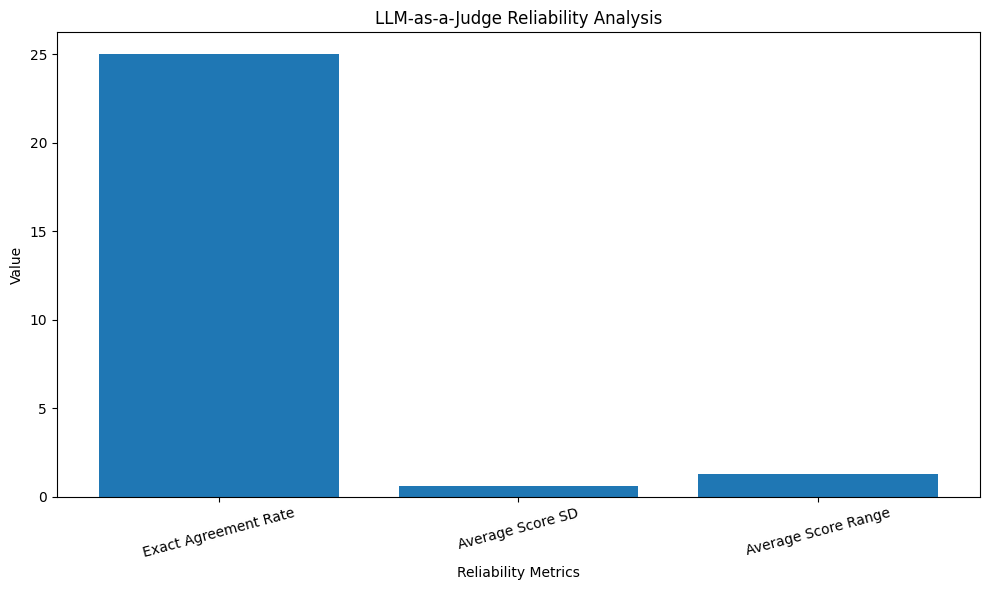


Saved: figures/reliability.png


In [ ]:
# ============================================
# SAVE RELIABILITY RESULTS + CREATE FIGURE
# ============================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# Create output directories
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)


# ============================================
# 1. SAVE RELIABILITY RESULTS AS CSV
# ============================================

reliability_csv_path = "results/reliability_results.csv"

df_reliability.to_csv(
    reliability_csv_path,
    index=False,
    encoding="utf-8"
)

print(f"Saved: {reliability_csv_path}")


# ============================================
# 2. CALCULATE RELIABILITY SUMMARY
# ============================================

questions = len(df_reliability)

exact_agreement = int(
    df_reliability["exact_agreement"].sum()
)

exact_agreement_rate = (
    exact_agreement / questions * 100
)

average_score = (
    df_reliability["mean_score"].mean()
)

average_score_sd = (
    df_reliability["std_score"].mean()
)

average_score_range = (
    df_reliability["score_range"].mean()
)

maximum_score_range = (
    df_reliability["score_range"].max()
)


# ============================================
# 3. PRINT SUMMARY
# ============================================

print("\n===== RELIABILITY SUMMARY =====")

print("Questions:", questions)

print(
    "Exact agreement:",
    exact_agreement
)

print(
    f"Exact agreement rate: "
    f"{exact_agreement_rate:.2f}%"
)

print(
    f"Average score: "
    f"{average_score:.3f}"
)

print(
    f"Average score SD: "
    f"{average_score_sd:.3f}"
)

print(
    f"Average score range: "
    f"{average_score_range:.3f}"
)

print(
    f"Maximum score range: "
    f"{maximum_score_range:.1f}"
)


# ============================================
# 4. CREATE RELIABILITY SUMMARY DATAFRAME
# ============================================

summary_df = pd.DataFrame({
    "Metric": [
        "Questions",
        "Exact Agreement",
        "Exact Agreement Rate (%)",
        "Average Score",
        "Average Score SD",
        "Average Score Range",
        "Maximum Score Range"
    ],

    "Value": [
        questions,
        exact_agreement,
        exact_agreement_rate,
        average_score,
        average_score_sd,
        average_score_range,
        maximum_score_range
    ]
})


# ============================================
# 5. CREATE RELIABILITY FIGURE
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

metrics = [
    "Exact Agreement Rate",
    "Average Score SD",
    "Average Score Range"
]

values = [
    exact_agreement_rate,
    average_score_sd,
    average_score_range
]

ax.bar(metrics, values)

ax.set_title(
    "LLM-as-a-Judge Reliability Analysis"
)

ax.set_ylabel("Value")

ax.set_xlabel("Reliability Metrics")

plt.xticks(rotation=15)

plt.tight_layout()


# Save figure
reliability_figure_path = "figures/reliability.png"

plt.savefig(
    reliability_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nSaved: {reliability_figure_path}")

In [ ]:
def clean_generated_answer(text):

    # Remove everything before "Answer:"
    if "Answer:" in text:
        text = text.split("Answer:", 1)[1]

    return text.strip()

In [ ]:
candidate_answers = []

for i, item in enumerate(mt_bench):

    question = item["turns"][0]

    # =========================
    # Generate Answer A
    # =========================

    prompt_a = f"""
Answer the following question clearly and accurately.

Question:
{question}

Answer:
"""

    result_a = target_llm(
        prompt_a,
        max_new_tokens=150,
        do_sample=False,
        return_full_text=False
    )

    answer_a = clean_generated_answer(
        result_a[0]["generated_text"]
    )


    # =========================
    # Generate Answer B
    # =========================

    prompt_b = f"""
Answer the following question clearly and accurately.

Question:
{question}

Answer:
"""

    result_b = target_llm(
        prompt_b,
        max_new_tokens=150,
        do_sample=True,
        temperature=0.8,
        return_full_text=False
    )

    answer_b = clean_generated_answer(
        result_b[0]["generated_text"]
    )


    candidate_answers.append({
        "question_id": item["question_id"],
        "category": item["category"],
        "question": question,
        "answer_a": answer_a,
        "answer_b": answer_b
    })

    print(f"{i+1}/80 completed")

[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more informati

1/80 completed


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


2/80 completed


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

78/80 completed


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


79/80 completed


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


80/80 completed


In [ ]:
print("Question:")

print(candidate_answers[0]["question"])

print("\nAnswer A:")

print(candidate_answers[0]["answer_a"])

print("\nAnswer B:")

print(candidate_answers[0]["answer_b"])

Question:
Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.

Answer A:
Welcome to our latest adventure in Hawaii! As we embark on this journey, we are eager to share with you some of the most memorable moments from our trip. From the vibrant culture of Hawaii to the breathtaking beauty of the islands, there is something for everyone to enjoy.
Our first stop was at the beautiful Waikiki Beach. The sand was warm and golden, and the water was crystal clear. We spent hours lounging on the beach, taking photos, and enjoying the sun. It was a perfect day to relax and soak up the sun.
Next, we visited the famous Ka'ala Lighthouse. This lighthouse is one of the oldest in the world, and it offers stunning views of the ocean. We took a boat tour around the

Answer B:
Hawaii is a state in the United States of America that has been my favorite place for years. The island's diverse culture and breathtaking natural beauty 

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "meta-llama/Llama-3.2-1B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)

judge_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("Llama 3.2 1B Instruct Judge loaded successfully!")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Llama 3.2 1B Instruct Judge loaded successfully!


In [ ]:
import re

def judge_pair(question, first_answer, second_answer):

    judge_prompt = f"""
You are an expert evaluator.

Evaluate two answers to the same question.

Question:
{question}

Answer A:
{first_answer}

Answer B:
{second_answer}

Compare the two answers based on:

1. Correctness
2. Relevance
3. Clarity
4. Instruction following

Choose the better answer.

You MUST choose exactly one:

Winner: A

or

Winner: B

Then give a short reason.

Use this format:

Winner: A or B
Reason: ...
"""

    inputs = tokenizer(
        judge_prompt,
        return_tensors="pt"
    ).to(judge_model.device)

    outputs = judge_model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False
    )

    evaluation = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return evaluation

In [ ]:
item = candidate_answers[0]

question = item["question"]
answer_a = item["answer_a"]
answer_b = item["answer_b"]

evaluation = judge_pair(
    question,
    answer_a,
    answer_b
)

print(evaluation)


You are an expert evaluator.

Evaluate two answers to the same question.

Question:
Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.

Answer A:
Welcome to our latest adventure in Hawaii! As we embark on this journey, we are eager to share with you some of the most memorable moments from our trip. From the vibrant culture of Hawaii to the breathtaking beauty of the islands, there is something for everyone to enjoy.
Our first stop was at the beautiful Waikiki Beach. The sand was warm and golden, and the water was crystal clear. We spent hours lounging on the beach, taking photos, and enjoying the sun. It was a perfect day to relax and soak up the sun.
Next, we visited the famous Ka'ala Lighthouse. This lighthouse is one of the oldest in the world, and it offers stunning views of the ocean. We took a boat tour around the

Answer B:
Hawaii is a state in the United States of America that has been my favorite pla

In [ ]:
evaluation_swapped = judge_pair(
    question,
    answer_b,
    answer_a
)

print(evaluation_swapped)


You are an expert evaluator.

Evaluate two answers to the same question.

Question:
Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.

Answer A:
Hawaii is a state in the United States of America that has been my favorite place for years. The island's diverse culture and breathtaking natural beauty make it a must-visit destination for travelers from all over the world. This post will focus on some of the most memorable cultural experiences and must-see attractions that I have witnessed while exploring this enchanting island.
As you wander around the bustling streets of Honolulu, you are likely to be greeted by a warm and welcoming atmosphere. The locals love to share stories and traditions with visitors, making it a great opportunity to learn about the local customs and traditions. In addition to visiting the famous Ka'apali Beaches, there are many other places that you can explore that showcase the island's 

In [ ]:
def extract_winner(text):

    match = re.search(
        r"Winner:\s*([AB])",
        text,
        re.IGNORECASE
    )

    if match:
        return match.group(1).upper()

    return None


def get_actual_winner(winner, order):

    if winner is None:
        return None

    if order == "AB":
        return winner

    elif order == "BA":

        if winner == "A":
            return "B"

        elif winner == "B":
            return "A"

    return None

In [ ]:
winner_1 = extract_winner(evaluation)
winner_2 = extract_winner(evaluation_swapped)

actual_1 = get_actual_winner(winner_1, "AB")
actual_2 = get_actual_winner(winner_2, "BA")

print("Original order winner:", actual_1)
print("Swapped order winner:", actual_2)

if actual_1 == actual_2:
    print("✅ Stable decision")
else:
    print("⚠️ Positional inconsistency detected")

Original order winner: A
Swapped order winner: B
⚠️ Positional inconsistency detected


In [ ]:
position_bias_results = []

for i, item in enumerate(candidate_answers):

    question = item["question"]
    answer_a = item["answer_a"]
    answer_b = item["answer_b"]

    # Original order: A, B
    eval_ab = judge_pair(
        question,
        answer_a,
        answer_b
    )

    winner_ab = extract_winner(eval_ab)

    # Swapped order: B, A
    eval_ba = judge_pair(
        question,
        answer_b,
        answer_a
    )

    winner_ba = extract_winner(eval_ba)

    # Convert both results to ORIGINAL answer identity
    actual_ab = get_actual_winner(winner_ab, "AB")
    actual_ba = get_actual_winner(winner_ba, "BA")

    # Position consistency
    if actual_ab is not None and actual_ba is not None:
        consistent = actual_ab == actual_ba
    else:
        consistent = None

    position_bias_results.append({
        "question_id": item["question_id"],
        "category": item["category"],

        "winner_ab": winner_ab,
        "winner_ba": winner_ba,

        "actual_winner_ab": actual_ab,
        "actual_winner_ba": actual_ba,

        "position_consistent": consistent,

        "evaluation_ab": eval_ab,
        "evaluation_ba": eval_ba
    })

    print(
        f"{i+1}/80 | "
        f"ID: {item['question_id']} | "
        f"AB: {winner_ab} | "
        f"BA: {winner_ba} | "
        f"Consistent: {consistent}"
    )

1/80 | ID: 81 | AB: A | BA: A | Consistent: False
2/80 | ID: 82 | AB: A | BA: A | Consistent: False
3/80 | ID: 83 | AB: A | BA: A | Consistent: False
4/80 | ID: 84 | AB: A | BA: A | Consistent: False
5/80 | ID: 85 | AB: A | BA: A | Consistent: False
6/80 | ID: 86 | AB: A | BA: A | Consistent: False
7/80 | ID: 87 | AB: A | BA: A | Consistent: False
8/80 | ID: 88 | AB: A | BA: A | Consistent: False
9/80 | ID: 89 | AB: A | BA: A | Consistent: False
10/80 | ID: 90 | AB: A | BA: A | Consistent: False
11/80 | ID: 91 | AB: A | BA: A | Consistent: False
12/80 | ID: 92 | AB: A | BA: A | Consistent: False
13/80 | ID: 93 | AB: A | BA: A | Consistent: False
14/80 | ID: 94 | AB: A | BA: A | Consistent: False
15/80 | ID: 95 | AB: A | BA: A | Consistent: False
16/80 | ID: 96 | AB: A | BA: A | Consistent: False
17/80 | ID: 97 | AB: A | BA: A | Consistent: False
18/80 | ID: 98 | AB: A | BA: A | Consistent: False
19/80 | ID: 99 | AB: A | BA: A | Consistent: False
20/80 | ID: 100 | AB: A | BA: A | Consis

In [ ]:
total = len(position_bias_results)

ab_a = sum(
    1 for x in position_bias_results
    if x["winner_ab"] == "A"
)

ab_b = sum(
    1 for x in position_bias_results
    if x["winner_ab"] == "B"
)

ba_a = sum(
    1 for x in position_bias_results
    if x["winner_ba"] == "A"
)

ba_b = sum(
    1 for x in position_bias_results
    if x["winner_ba"] == "B"
)

consistent = sum(
    1 for x in position_bias_results
    if x["position_consistent"] is True
)

inconsistent = sum(
    1 for x in position_bias_results
    if x["position_consistent"] is False
)

print("===== POSITION BIAS SUMMARY =====")

print("Total questions:", total)

print("\nOriginal order (A vs B):")
print("Winner A:", ab_a)
print("Winner B:", ab_b)

print("\nSwapped order (B vs A):")
print("Winner A:", ba_a)
print("Winner B:", ba_b)

print("\nConsistency:")
print("Consistent:", consistent)
print("Inconsistent:", inconsistent)

print("\nRates:")
print("AB → A rate:", round(ab_a / total * 100, 2), "%")
print("BA → A rate:", round(ba_a / total * 100, 2), "%")
print("Consistency rate:", round(consistent / total * 100, 2), "%")
print("Inconsistency rate:", round(inconsistent / total * 100, 2), "%")

===== POSITION BIAS SUMMARY =====
Total questions: 80

Original order (A vs B):
Winner A: 80
Winner B: 0

Swapped order (B vs A):
Winner A: 80
Winner B: 0

Consistency:
Consistent: 0
Inconsistent: 80

Rates:
AB → A rate: 100.0 %
BA → A rate: 100.0 %
Consistency rate: 0.0 %
Inconsistency rate: 100.0 %


In [ ]:
first_position_wins = 0
second_position_wins = 0
valid_comparisons = 0

for x in position_bias_results:

    if x["winner_ab"] in ["A", "B"]:
        valid_comparisons += 1

        if x["winner_ab"] == "A":
            first_position_wins += 1
        else:
            second_position_wins += 1

    if x["winner_ba"] in ["A", "B"]:
        valid_comparisons += 1

        if x["winner_ba"] == "A":
            first_position_wins += 1
        else:
            second_position_wins += 1


print("===== POSITION PREFERENCE =====")

print("Valid comparisons:", valid_comparisons)
print("First-position wins:", first_position_wins)
print("Second-position wins:", second_position_wins)

print(
    "First-position preference:",
    round(first_position_wins / valid_comparisons * 100, 2),
    "%"
)

print(
    "Second-position preference:",
    round(second_position_wins / valid_comparisons * 100, 2),
    "%"
)

===== POSITION PREFERENCE =====
Valid comparisons: 160
First-position wins: 160
Second-position wins: 0
First-position preference: 100.0 %
Second-position preference: 0.0 %


Saved: results/position_bias_results.csv

===== POSITION BIAS SUMMARY =====
Total questions: 80
Valid comparisons: 160

First-position wins: 160
Second-position wins: 0

First-position preference: 100.00%
Second-position preference: 0.00%

Answer Identity Consistency:
Consistent: 0
Inconsistent: 80
Consistency rate: 0.00%
Inconsistency / Flip rate: 100.00%

Saved: results/position_bias_summary.csv


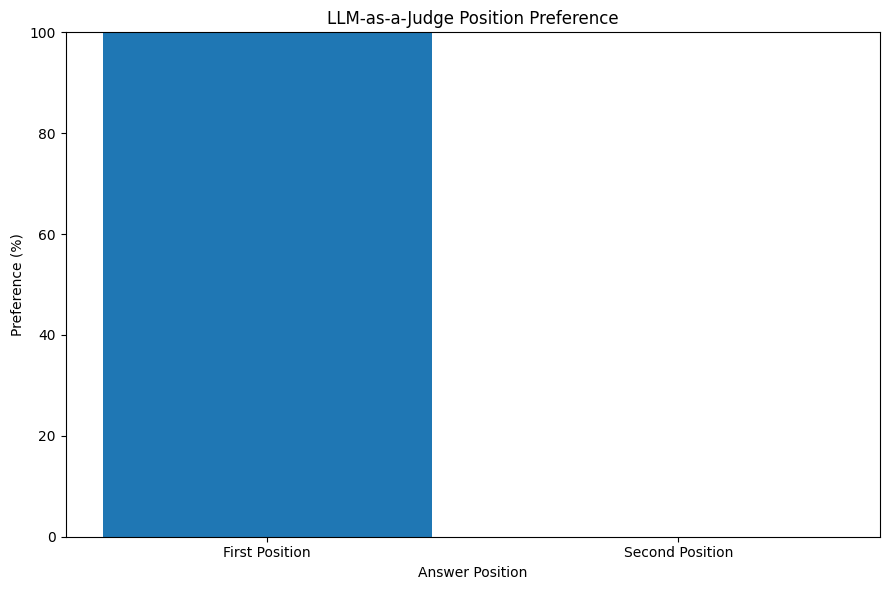

Saved: figures/position_bias.png


In [ ]:
# ============================================
# SAVE POSITION BIAS RESULTS + CREATE FIGURE
# ============================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# Create folders
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)


# ============================================
# 1. SAVE RAW POSITION BIAS RESULTS
# ============================================

position_bias_csv_path = "results/position_bias_results.csv"

position_bias_df = pd.DataFrame(position_bias_results)

position_bias_df.to_csv(
    position_bias_csv_path,
    index=False,
    encoding="utf-8"
)

print(f"Saved: {position_bias_csv_path}")


# ============================================
# 2. CALCULATE POSITION PREFERENCE
# ============================================

first_position_wins = 0
second_position_wins = 0
valid_comparisons = 0

for x in position_bias_results:

    # ----------------------------------------
    # Original order: A is FIRST position
    # ----------------------------------------

    if x["winner_ab"] in ["A", "B"]:

        valid_comparisons += 1

        if x["winner_ab"] == "A":
            # Answer A is in first position
            first_position_wins += 1
        else:
            # Answer B is in second position
            second_position_wins += 1


    # ----------------------------------------
    # Swapped order: B is FIRST position
    #
    # Important:
    # judge_pair() always labels first_answer
    # as "Answer A".
    #
    # Therefore:
    # winner_ba == A -> FIRST position
    # winner_ba == B -> SECOND position
    # ----------------------------------------

    if x["winner_ba"] in ["A", "B"]:

        valid_comparisons += 1

        if x["winner_ba"] == "A":
            # First presented answer won
            first_position_wins += 1
        else:
            # Second presented answer won
            second_position_wins += 1


# ============================================
# 3. CALCULATE POSITION PREFERENCE RATES
# ============================================

if valid_comparisons > 0:

    first_position_rate = (
        first_position_wins / valid_comparisons * 100
    )

    second_position_rate = (
        second_position_wins / valid_comparisons * 100
    )

else:

    first_position_rate = 0
    second_position_rate = 0


# ============================================
# 4. ANSWER IDENTITY CONSISTENCY ANALYSIS
# ============================================

consistent = sum(
    1
    for x in position_bias_results
    if x["position_consistent"] is True
)

inconsistent = sum(
    1
    for x in position_bias_results
    if x["position_consistent"] is False
)

total_questions = len(position_bias_results)

if total_questions > 0:

    consistency_rate = (
        consistent / total_questions * 100
    )

    inconsistency_rate = (
        inconsistent / total_questions * 100
    )

else:

    consistency_rate = 0
    inconsistency_rate = 0


# ============================================
# 5. CALCULATE ANSWER FLIP RATE
# ============================================

flip_rate = inconsistency_rate


# ============================================
# 6. PRINT POSITION BIAS SUMMARY
# ============================================

print("\n===== POSITION BIAS SUMMARY =====")

print("Total questions:", total_questions)

print("Valid comparisons:", valid_comparisons)

print("\nFirst-position wins:", first_position_wins)

print("Second-position wins:", second_position_wins)

print(
    f"\nFirst-position preference: "
    f"{first_position_rate:.2f}%"
)

print(
    f"Second-position preference: "
    f"{second_position_rate:.2f}%"
)

print("\nAnswer Identity Consistency:")

print("Consistent:", consistent)

print("Inconsistent:", inconsistent)

print(
    f"Consistency rate: "
    f"{consistency_rate:.2f}%"
)

print(
    f"Inconsistency / Flip rate: "
    f"{flip_rate:.2f}%"
)


# ============================================
# 7. CREATE SUMMARY CSV
# ============================================

position_bias_summary = pd.DataFrame({

    "Metric": [

        "Total Questions",

        "Valid Comparisons",

        "First-Position Wins",

        "Second-Position Wins",

        "First-Position Preference (%)",

        "Second-Position Preference (%)",

        "Consistent Decisions",

        "Inconsistent Decisions",

        "Consistency Rate (%)",

        "Inconsistency / Flip Rate (%)"
    ],

    "Value": [

        total_questions,

        valid_comparisons,

        first_position_wins,

        second_position_wins,

        first_position_rate,

        second_position_rate,

        consistent,

        inconsistent,

        consistency_rate,

        flip_rate
    ]
})


summary_csv_path = "results/position_bias_summary.csv"

position_bias_summary.to_csv(
    summary_csv_path,
    index=False,
    encoding="utf-8"
)

print(
    f"\nSaved: {summary_csv_path}"
)


# ============================================
# 8. CREATE POSITION BIAS FIGURE
# ============================================

labels = [
    "First Position",
    "Second Position"
]

values = [
    first_position_rate,
    second_position_rate
]

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    labels,
    values
)

ax.set_title(
    "LLM-as-a-Judge Position Preference"
)

ax.set_ylabel(
    "Preference (%)"
)

ax.set_xlabel(
    "Answer Position"
)

ax.set_ylim(
    0,
    100
)

plt.tight_layout()


# ============================================
# 9. SAVE PNG
# ============================================

position_bias_figure_path = "figures/position_bias.png"

plt.savefig(
    position_bias_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {position_bias_figure_path}"
)

In [ ]:
!pip install -q transformers accelerate sentencepiece
import json
import re
import torch

from transformers import pipeline

In [ ]:
import requests

url = "https://raw.githubusercontent.com/lm-sys/FastChat/main/fastchat/llm_judge/data/mt_bench/question.jsonl"

response = requests.get(url)
response.raise_for_status()

mt_bench = [
    json.loads(line)
    for line in response.text.strip().split("\n")
]

print("Total questions:", len(mt_bench))

Total questions: 80


In [ ]:
for item in mt_bench[:3]:
    print("ID:", item["question_id"])
    print("Category:", item["category"])
    print("Question:", item["turns"][0])
    print("-" * 80)

ID: 81
Category: writing
Question: Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.
--------------------------------------------------------------------------------
ID: 82
Category: writing
Question: Draft a professional email seeking your supervisor's feedback on the 'Quarterly Financial Report' you prepared. Ask specifically about the data analysis, presentation style, and the clarity of conclusions drawn. Keep the email short and to the point.
--------------------------------------------------------------------------------
ID: 83
Category: writing
Question: Imagine you are writing a blog post comparing two popular smartphone models. Develop an outline for the blog post, including key points and subheadings to effectively compare and contrast the features, performance, and user experience of the two models. Please answer in fewer than 200 words.
-------------------------------------------------------------

In [ ]:
target_llm = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-0.5B-Instruct",
    device=0 if torch.cuda.is_available() else -1
)

print("Qwen Target LLM loaded successfully!")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen Target LLM loaded successfully!


In [ ]:
def create_short_prompt(question):

    prompt = f"""
Answer the question below.

Write ONLY the answer to the question.

The answer must be concise but complete.
Include the essential information needed to answer the question.
Do not add unnecessary details.
Do not explain what you are doing.
Do not mention these instructions.

QUESTION:
{question}

ANSWER:
"""

    return prompt

In [ ]:
def create_long_prompt(question):

    prompt = f"""
Answer the question below.

Write ONLY the answer to the question.

The answer should be detailed and comprehensive.
Explain the important points clearly.
Provide useful context and reasoning when appropriate.
Give substantially more detail than a concise answer.
Do not add irrelevant information.
Do not explain what you are doing.
Do not mention these instructions.

QUESTION:
{question}

ANSWER:
"""

    return prompt

In [ ]:
test_question = mt_bench[0]["turns"][0]

print("QUESTION:")
print(test_question)

QUESTION:
Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.


In [ ]:
short_prompt = create_short_prompt(test_question)

short_result = target_llm(
    short_prompt,
    max_new_tokens=100,
    do_sample=False,
    return_full_text=False
)

short_answer = short_result[0]["generated_text"].strip()

print("=" * 80)
print("SHORT ANSWER:")
print(short_answer)

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


SHORT ANSWER:
Hawaii is a paradise for travelers who love adventure and relaxation. The island of Hawaii is known for its stunning beaches, lush rainforests, and vibrant culture. In this blog post, we will explore some of the most memorable experiences that visitors can have in Hawaii.

Firstly, let's talk about the cultural experiences that make Hawaii unique. One of the most significant aspects of Hawaii is its indigenous culture. Visitors can immerse themselves in traditional Hawaiian customs such as hula dancing, lei-making,


In [ ]:
long_prompt = create_long_prompt(test_question)

long_result = target_llm(
    long_prompt,
    max_new_tokens=200,
    do_sample=False,
    return_full_text=False
)

long_answer = long_result[0]["generated_text"].strip()

print("=" * 80)
print("LONG ANSWER:")
print(long_answer)

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


LONG ANSWER:
Welcome to Hawaii! This is my latest adventure in this beautiful island paradise. I had the opportunity to visit the Hawaiian Islands for a week, and it was truly unforgettable. The culture of Hawaii is rich and diverse, with its own unique traditions and customs that make it a fascinating place to explore.

One of the most impressive things about Hawaii is its stunning natural beauty. From the lush green forests of Kauai to the crystal-clear waters of Oahu, there's something for everyone. The beaches of Waikiki and Molokai offer breathtaking views of the ocean, while the islands themselves are home to some of the world's most beautiful landscapes.

One of the highlights of my trip was visiting the Hanauma Bay National Wildlife Refuge. It's a prime example of Hawaii's efforts to protect its wildlife, and it's a great spot for birdwatching. The refuge is located on the north shore of Oahu, and it offers visitors a chance to see a variety of birds, including the


In [ ]:
print("=" * 80)

print("SHORT WORD COUNT:")
print(len(short_answer.split()))

print("\nLONG WORD COUNT:")
print(len(long_answer.split()))

SHORT WORD COUNT:
81

LONG WORD COUNT:
166


In [ ]:
verbosity_pairs = []

for i, item in enumerate(mt_bench):

    question = item["turns"][0]

    try:

        # -------------------------
        # Generate SHORT answer
        # -------------------------

        short_prompt = create_short_prompt(question)

        short_result = target_llm(
            short_prompt,
            max_new_tokens=100,
            do_sample=False,
            return_full_text=False
        )

        short_answer = short_result[0]["generated_text"].strip()


        # -------------------------
        # Generate LONG answer
        # -------------------------

        long_prompt = create_long_prompt(question)

        long_result = target_llm(
            long_prompt,
            max_new_tokens=200,
            do_sample=False,
            return_full_text=False
        )

        long_answer = long_result[0]["generated_text"].strip()


        # -------------------------
        # Save
        # -------------------------

        verbosity_pairs.append({
            "question_id": item["question_id"],
            "category": item["category"],
            "question": question,
            "short_answer": short_answer,
            "long_answer": long_answer
        })


        # -------------------------
        # Word count
        # -------------------------

        short_words = len(short_answer.split())
        long_words = len(long_answer.split())


        print(
            f"{i+1}/80 | "
            f"ID: {item['question_id']} | "
            f"Short: {short_words} words | "
            f"Long: {long_words} words"
        )


    except Exception as e:

        print(
            f"{i+1}/80 | "
            f"ID: {item['question_id']} | "
            f"ERROR: {e}"
        )

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


1/80 | ID: 81 | Short: 81 words | Long: 166 words


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


2/80 | ID: 82 | Short: 84 words | Long: 174 words


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

78/80 | ID: 158 | Short: 78 words | Long: 157 words


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


79/80 | ID: 159 | Short: 73 words | Long: 155 words


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


80/80 | ID: 160 | Short: 61 words | Long: 149 words


In [ ]:
from transformers import pipeline
import torch

judge_llm = pipeline(
    "text-generation",
    model="meta-llama/Llama-3.2-1B-Instruct",
    device=0 if torch.cuda.is_available() else -1
)

print("Llama Judge loaded successfully!")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Llama Judge loaded successfully!


In [ ]:
judge_tokenizer = judge_llm.tokenizer

In [ ]:
def create_verbosity_judge_prompt(question, short_answer, long_answer):

    messages = [
        {
            "role": "system",
            "content": "You are a strict evaluator. Choose the better answer."
        },
        {
            "role": "user",
            "content": f"""
QUESTION:
{question}

SHORT ANSWER:
{short_answer}

LONG ANSWER:
{long_answer}

Which answer is better?

Consider:
- Correctness
- Relevance
- Completeness
- Clarity
- Usefulness

Do NOT prefer the long answer simply because it is longer.
Do NOT reward verbosity itself.

Your answer must be exactly ONE of these:

SHORT

or

LONG

Do not explain your answer.
"""
        }
    ]

    return messages

In [ ]:
test_item = verbosity_pairs[0]

print("QUESTION:")
print(test_item["question"])

print("\n--- SHORT ANSWER ---")
print(test_item["short_answer"])

print("\n--- LONG ANSWER ---")
print(test_item["long_answer"])

QUESTION:
Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.

--- SHORT ANSWER ---
Hawaii is a paradise for travelers who love adventure and relaxation. The island of Hawaii is known for its stunning beaches, lush rainforests, and vibrant culture. In this blog post, we will explore some of the most memorable experiences that visitors can have in Hawaii.

Firstly, let's talk about the cultural experiences that make Hawaii unique. One of the most significant aspects of Hawaii is its indigenous culture. Visitors can immerse themselves in traditional Hawaiian customs such as hula dancing, lei-making,

--- LONG ANSWER ---
Welcome to Hawaii! This is my latest adventure in this beautiful island paradise. I had the opportunity to visit the Hawaiian Islands for a week, and it was truly unforgettable. The culture of Hawaii is rich and diverse, with its own unique traditions and customs that make it a fascinating place t

In [ ]:
test_item = verbosity_pairs[0]

messages = [
    {
        "role": "system",
        "content": "You are an evaluator. Choose exactly one label."
    },
    {
        "role": "user",
        "content": f"""
Question:
{test_item["question"]}

SHORT ANSWER:
{test_item["short_answer"]}

LONG ANSWER:
{test_item["long_answer"]}

Which answer is better?

Answer with exactly ONE word:
SHORT
or
LONG
"""
    }
]

judge_input = judge_tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

judge_result = judge_llm(
    judge_input,
    max_new_tokens=3,
    do_sample=False,
    return_full_text=False
)

judge_output = judge_result[0]["generated_text"].strip()

print("Judge output:", repr(judge_output))

[transformers] Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Judge output: 'LONG'


In [ ]:
import json
import re

verbosity_judgments = []

for i, item in enumerate(verbosity_pairs):

    print(f"\nProcessing {i+1}/80 | ID: {item['question_id']}")

    try:

        # --------------------------------
        # 1. Create judge messages
        # --------------------------------

        messages = [
            {
                "role": "system",
                "content": "You are an evaluator. Choose exactly one label."
            },
            {
                "role": "user",
                "content": f"""
Question:

{item["question"]}

SHORT ANSWER:

{item["short_answer"]}

LONG ANSWER:

{item["long_answer"]}

Which answer is better?

Answer with exactly ONE word:

SHORT

or

LONG
"""
            }
        ]

        # --------------------------------
        # 2. Convert to Llama chat format
        # --------------------------------

        judge_input = judge_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        # --------------------------------
        # 3. Llama judges the answers
        # --------------------------------

        judge_result = judge_llm(
            judge_input,
            max_new_tokens=3,
            do_sample=False,
            return_full_text=False
        )

        # --------------------------------
        # 4. Get Llama output
        # --------------------------------

        judge_output = judge_result[0]["generated_text"].strip()

        # --------------------------------
        # 5. Extract winner
        # --------------------------------

        match = re.search(
            r"\b(SHORT|LONG)\b",
            judge_output.upper()
        )

        if match:
            winner = match.group(1)
        else:
            winner = None

        # --------------------------------
        # 6. Save result
        # --------------------------------

        result = {
            "question_id": item["question_id"],
            "category": item["category"],
            "question": item["question"],
            "short_answer": item["short_answer"],
            "long_answer": item["long_answer"],
            "judge_output": judge_output,
            "winner": winner
        }

        verbosity_judgments.append(result)

        print(
            f"Judge output: {repr(judge_output)} | "
            f"Winner: {winner}"
        )

    except Exception as e:

        print(
            f"ERROR on ID {item['question_id']}: {e}"
        )

        verbosity_judgments.append({
            "question_id": item["question_id"],
            "category": item["category"],
            "question": item["question"],
            "short_answer": item["short_answer"],
            "long_answer": item["long_answer"],
            "judge_output": None,
            "winner": None,
            "error": str(e)
        })

[transformers] Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Processing 1/80 | ID: 81


[transformers] Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Judge output: 'LONG' | Winner: LONG

Processing 2/80 | ID: 82


[transformers] Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Judge output: 'LONG' | Winner: LONG

Processing 78/80 | ID: 158


[transformers] Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Judge output: 'LONG' | Winner: LONG

Processing 79/80 | ID: 159


[transformers] Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Judge output: 'LONG' | Winner: LONG

Processing 80/80 | ID: 160
Judge output: 'LONG' | Winner: LONG


In [ ]:
short_wins = sum(
    1 for x in verbosity_judgments
    if x["winner"] == "SHORT"
)

long_wins = sum(
    1 for x in verbosity_judgments
    if x["winner"] == "LONG"
)

missing = sum(
    1 for x in verbosity_judgments
    if x["winner"] is None
)

print("SHORT wins:", short_wins)
print("LONG wins:", long_wins)
print("Missing/Invalid:", missing)
print("Total:", len(verbosity_judgments))

print("====\n**Percentage:**\n")

total_valid = short_wins + long_wins

if total_valid > 0:
    print(
        f"SHORT preference: "
        f"{short_wins / total_valid * 100:.2f}%"
    )

    print(
        f"LONG preference: "
        f"{long_wins / total_valid * 100:.2f}%"
    )

SHORT wins: 10
LONG wins: 63
Missing/Invalid: 7
Total: 80
====
**Percentage:**

SHORT preference: 13.70%
LONG preference: 86.30%


Saved: results/verbosity_bias_results.csv

===== VERBOSITY BIAS SUMMARY =====
Total questions: 80
Valid judgments: 73
Missing/Invalid: 7

SHORT wins: 10
LONG wins: 63

SHORT preference: 13.70%
LONG preference: 86.30%

Valid judgment rate: 91.25%
Missing/Invalid rate: 8.75%

Saved: results/verbosity_bias_summary.csv


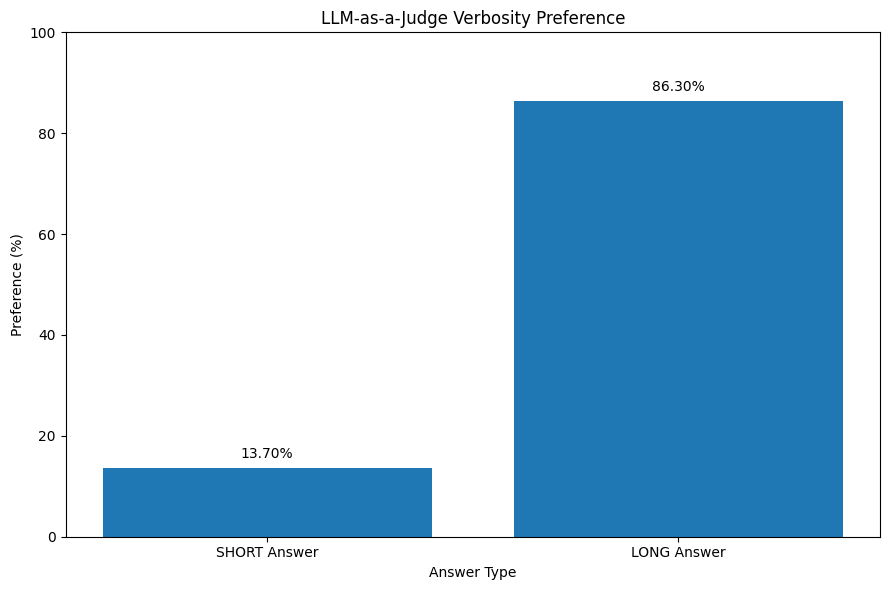

Saved: figures/verbosity_bias.png


In [ ]:
# ============================================
# SAVE VERBOSITY BIAS RESULTS + CREATE FIGURE
# ============================================

import os
import pandas as pd
import matplotlib.pyplot as plt


# ============================================
# 1. CREATE FOLDERS
# ============================================

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)


# ============================================
# 2. SAVE RAW VERBOSITY JUDGMENTS
# ============================================

verbosity_results_csv_path = (
    "results/verbosity_bias_results.csv"
)

verbosity_df = pd.DataFrame(
    verbosity_judgments
)

verbosity_df.to_csv(
    verbosity_results_csv_path,
    index=False,
    encoding="utf-8"
)

print(
    f"Saved: {verbosity_results_csv_path}"
)


# ============================================
# 3. CALCULATE VERBOSITY PREFERENCE
# ============================================

short_wins = sum(
    1
    for x in verbosity_judgments
    if x.get("winner") == "SHORT"
)

long_wins = sum(
    1
    for x in verbosity_judgments
    if x.get("winner") == "LONG"
)

missing = sum(
    1
    for x in verbosity_judgments
    if x.get("winner") is None
)

total_questions = len(
    verbosity_judgments
)

total_valid = short_wins + long_wins


# ============================================
# 4. CALCULATE PERCENTAGES
# ============================================

if total_valid > 0:

    short_preference = (
        short_wins / total_valid * 100
    )

    long_preference = (
        long_wins / total_valid * 100
    )

else:

    short_preference = 0
    long_preference = 0


# ============================================
# 5. VALID / INVALID RATES
# ============================================

if total_questions > 0:

    valid_rate = (
        total_valid / total_questions * 100
    )

    missing_rate = (
        missing / total_questions * 100
    )

else:

    valid_rate = 0
    missing_rate = 0


# ============================================
# 6. PRINT VERBOSITY BIAS SUMMARY
# ============================================

print("\n===== VERBOSITY BIAS SUMMARY =====")

print(
    "Total questions:",
    total_questions
)

print(
    "Valid judgments:",
    total_valid
)

print(
    "Missing/Invalid:",
    missing
)

print("\nSHORT wins:", short_wins)

print("LONG wins:", long_wins)

print(
    f"\nSHORT preference: "
    f"{short_preference:.2f}%"
)

print(
    f"LONG preference: "
    f"{long_preference:.2f}%"
)

print(
    f"\nValid judgment rate: "
    f"{valid_rate:.2f}%"
)

print(
    f"Missing/Invalid rate: "
    f"{missing_rate:.2f}%"
)


# ============================================
# 7. CREATE SUMMARY CSV
# ============================================

verbosity_bias_summary = pd.DataFrame({

    "Metric": [

        "Total Questions",

        "Valid Judgments",

        "Missing / Invalid",

        "SHORT Wins",

        "LONG Wins",

        "SHORT Preference (%)",

        "LONG Preference (%)",

        "Valid Judgment Rate (%)",

        "Missing / Invalid Rate (%)"
    ],

    "Value": [

        total_questions,

        total_valid,

        missing,

        short_wins,

        long_wins,

        short_preference,

        long_preference,

        valid_rate,

        missing_rate
    ]
})


verbosity_summary_csv_path = (
    "results/verbosity_bias_summary.csv"
)

verbosity_bias_summary.to_csv(
    verbosity_summary_csv_path,
    index=False,
    encoding="utf-8"
)

print(
    f"\nSaved: {verbosity_summary_csv_path}"
)


# ============================================
# 8. CREATE VERBOSITY PREFERENCE FIGURE
# ============================================

labels = [
    "SHORT Answer",
    "LONG Answer"
]

values = [
    short_preference,
    long_preference
]


fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.bar(
    labels,
    values
)

ax.set_title(
    "LLM-as-a-Judge Verbosity Preference"
)

ax.set_ylabel(
    "Preference (%)"
)

ax.set_xlabel(
    "Answer Type"
)

ax.set_ylim(
    0,
    100
)


# Add percentage values above bars

for i, value in enumerate(values):

    ax.text(
        i,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )


plt.tight_layout()


# ============================================
# 9. SAVE PNG
# ============================================

verbosity_figure_path = (
    "figures/verbosity_bias.png"
)

plt.savefig(
    verbosity_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {verbosity_figure_path}"
)